In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

hbarc = 197.327053                    #(* [MeV fm] *)
MN0 = (938.27231 + 939.56563)/2       #(* average nucleon mass [MeV] *)
MN  = MN0/hbarc**2			          #(* average nucleon mass in units [1/(MeV fm^2)] *)

1. Read (and check) the matrix elements from data file.

Rows: 632, Columns: 632


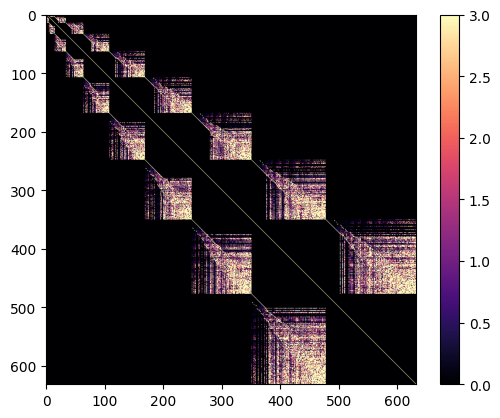

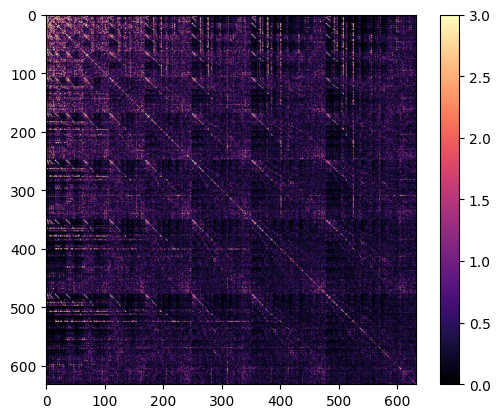

Symmetric? True


In [3]:
TMat = np.loadtxt("kinetic_EMax20_hw20.dat")
VMat = np.loadtxt("chi2b3b_EMax20_hw20.dat")
HMat = TMat + VMat

rows, cols = HMat.shape
print(f"Rows: {rows}, Columns: {cols}")

# display TMat and VMat
plt.imshow(np.abs(TMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()
plt.imshow(np.abs(VMat), vmin=0, vmax=3, cmap="magma")
plt.colorbar()
plt.show()

# basic check
print("Symmetric?", np.allclose(HMat, HMat.T))

2. Implement the SRG-evolution of the Hamiltonian using the kinetic
energy T and the potential matrix elements

In [4]:
def commutator(A, B):
    """Return [A, B] = AB - BA."""
    return A @ B - B @ A

def wegner_generator(H, T):
    """Wegner generator eta = [T, H]."""
    return commutator(T, H)

def srg_rhs(H):
    """Right-hand side of dH/da = MN^2 * [eta, H]"""
    eta = wegner_generator(H, TMat)
    dHda = MN**2 * commutator(eta, H)
    return dHda

#def srg_rhs_open(H):
#    """Right-hand side of dH/da = MN^2 * (T H(a) H(a) - 2 H(a) T H(a) + H(a) H(a) T)"""
#    dHda = MN**2 * (TMat @ H @ H - 2 * H @ TMat @ H + H @ H @ TMat)
#    return dHda

EtaMat = commutator(TMat, HMat)

print("Antisymmetric?", np.allclose(EtaMat, -EtaMat.T))

Antisymmetric? True


3. Solve the flow equation:
\begin{equation}
    \begin{aligned}
        \frac{d}{da}H(a) &= M_N^2 [[T,H(a)],H(a)] \\
                         &= M_N^2 (T H(a) H(a) - 2 H(a) T H(a) + H(a) H(a) T )
    \end{aligned}
\end{equation}
where it was chosen the SRG generator to be
\begin{equation}
    \eta(a) = [T,H(a)]
\end{equation}
known as the Wegner generator.

4. Solve this matrix evolution equation using the simplest possible
algorithm for treating ordinary differential equations numerically,
the so-called Euler algorithm.

Here I also implemented the RK4 algorithmm, which has higher order $(o(h^4))$ numerical accuracy, in order to make a comparison between the two methods



In [ ]:
#create an empty SRG evolution storage for each integration method, with initial value VMat
VMatEuler = {}
VMatRK4 = {} 
VMatEuler[0.0] = VMat
VMatRK4[0.0] = VMat

a0 = 0.0                                            #initial value
aDel = 0.0001                                       #integration step
MatIndexDistance = 0.05                             #distance between indexes of VMatEuler. This must be the same for RK4 and Euler in order for the next code boxes to work!
NElements = 5

def euler_integration(a0, aDel, IntegrationSteps, rhs):
    HMat = TMat + VMatEuler[a0]

    for _ in range(IntegrationSteps):
        HMatDel = aDel * rhs(HMat)
        HMat +=  HMatDel

    return HMat - TMat

def rk4_integration(a0, aDel, IntegrationSteps, rhs):
    HMat = TMat + VMatRK4[a0]

    for _ in range(IntegrationSteps):
        k1 = rhs(HMat)
        k2 = rhs(HMat + aDel*k1/2)
        k3 = rhs(HMat + aDel*k2/2)
        k4 = rhs(HMat + aDel*k3)

        HMat += aDel/6 * (k1 + 2*k2 + 2*k3 + k4)

    return HMat - TMat

def generate_VMat_elements(NElements, VMat, integration_method, a0, aDel, MatIndexDistance, rhs):
    IntegrationSteps = int(MatIndexDistance / aDel) #takes about one minute and a half when  = 500 for Euler, = 50 for RK4, with NElements = 5

    for i in range(NElements):
        a = np.round(a0 + i * MatIndexDistance, 5)
        aNext = np.round(a + MatIndexDistance, 5)
        VMat[aNext] = integration_method(a, aDel, IntegrationSteps, rhs)

generate_VMat_elements(NElements, VMatEuler, euler_integration, a0, aDel, MatIndexDistance, srg_rhs)
#better value for RK4 integration
aDel = 0.001
generate_VMat_elements(NElements, VMatRK4, rk4_integration, a0, aDel, MatIndexDistance, srg_rhs)


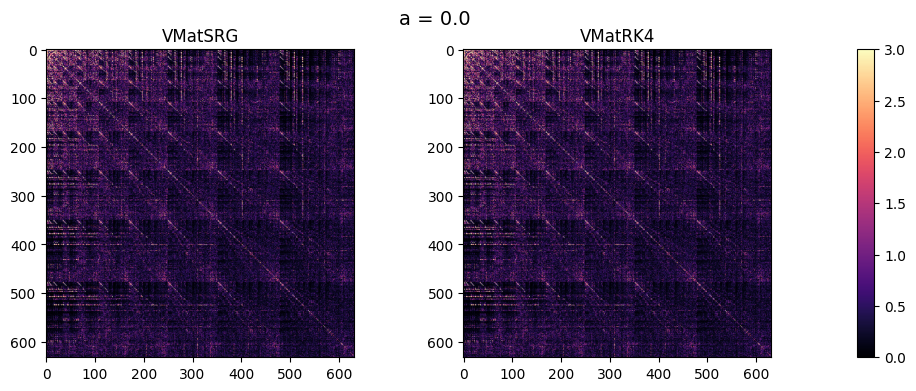

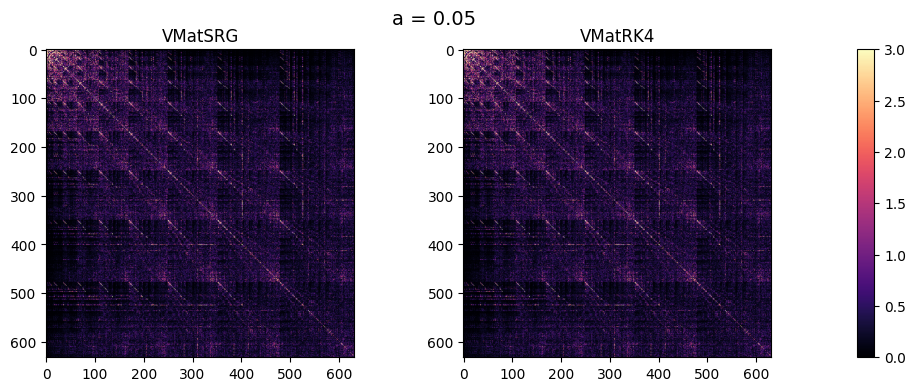

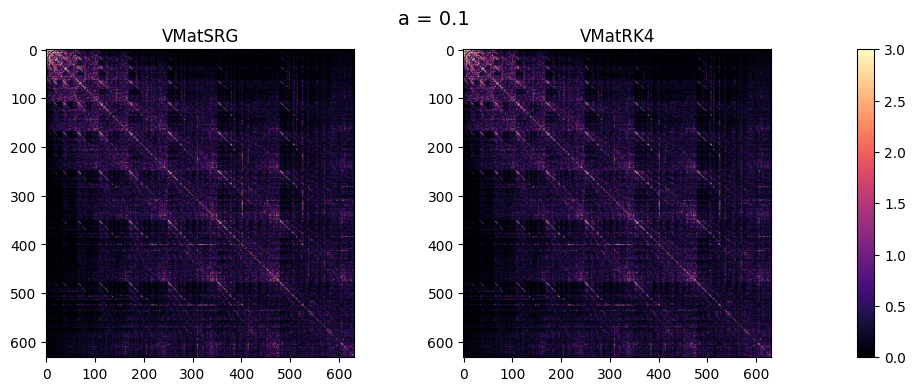

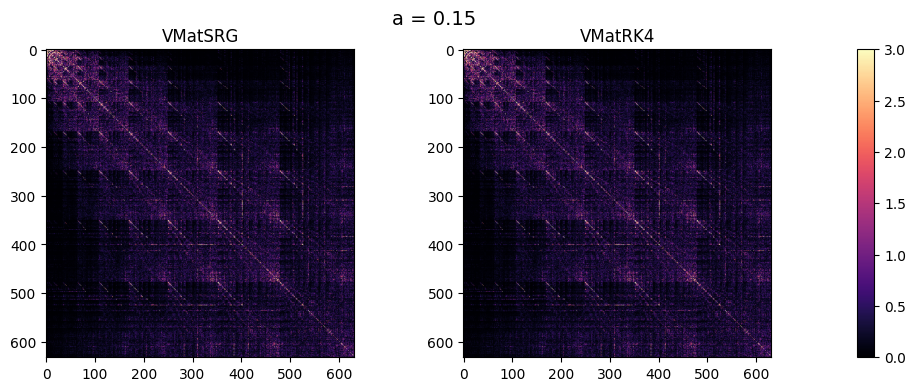

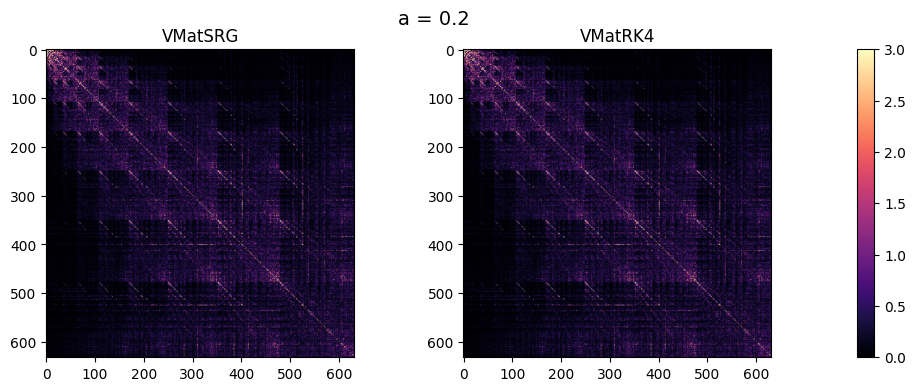

In [6]:
#display VMatSRG evolution
for i in range(NElements):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    Figure = plt.figure(figsize=(11, 4))

    Layout = Figure.add_gridspec(1, 3, width_ratios=[1, 1, 0.05], wspace=0.25)

    AxisEuler = Figure.add_subplot(Layout[0, 0])
    AxisRK4 = Figure.add_subplot(Layout[0, 1])
    AxisColorbar = Figure.add_subplot(Layout[0, 2])

    ImageEuler = AxisEuler.imshow(np.abs(VMatEuler[a]), vmin=0, vmax=3, cmap="magma")
    AxisEuler.set_title("VMatSRG")

    ImageRK4 = AxisRK4.imshow(np.abs(VMatRK4[a]), vmin=0, vmax=3, cmap="magma")
    AxisRK4.set_title("VMatRK4")

    Figure.colorbar(ImageEuler, cax=AxisColorbar)
    Figure.suptitle(f"a = {a}", fontsize=14)
    plt.show()

5. Finally, you can solve the exact Schrödinger equation for the triton
via a matrix eigenvalue problem, which corresponds to a full-
fledged No-Core Shell Model calculation.

The min eigenvalue in magnitude, corresponding to a = 0.0 in Euler integration, is: -8.07045774855503
The min eigenvalue in magnitude, corresponding to a = 0.0 in RK4 integration, is: -8.07045774855503


The min eigenvalue in magnitude, corresponding to a = 0.05 in Euler integration, is: -8.088923646958053
The min eigenvalue in magnitude, corresponding to a = 0.05 in RK4 integration, is: -8.07045924671243


The min eigenvalue in magnitude, corresponding to a = 0.1 in Euler integration, is: -8.089781784793256
The min eigenvalue in magnitude, corresponding to a = 0.1 in RK4 integration, is: -8.070459251806325


The min eigenvalue in magnitude, corresponding to a = 0.15 in Euler integration, is: -8.09002001307715
The min eigenvalue in magnitude, corresponding to a = 0.15 in RK4 integration, is: -8.070459252067744


The min eigenvalue in magnitude, corresponding to a = 0.2 in Euler integration, is: -8.09012923413538
The min eigenvalue in magnitude, corresponding to a = 0.2 in RK4 integrati

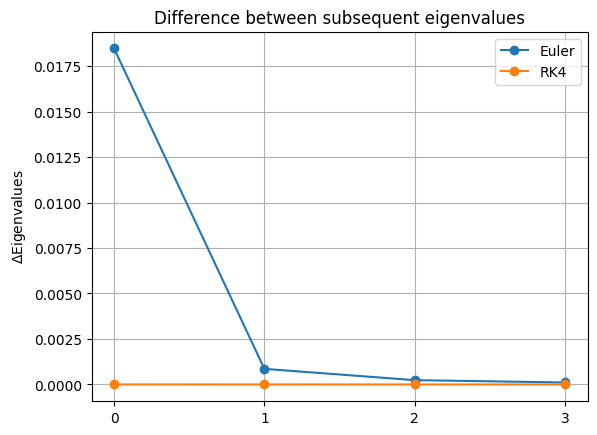

In [7]:
def min_eigenvalue(VMatSRG): #implemented following Robert Roth’s project instructions
    HMat = TMat + VMatSRG

    Eigenvalues = np.linalg.eigvalsh(HMat)
    FiveLowestMagnitude = Eigenvalues[np.argsort(np.abs(Eigenvalues))[:5]]

    Min_Eigenvalue = np.min(FiveLowestMagnitude)
    return Min_Eigenvalue

EigenvalueDifferenceEuler = []
EigenvalueDifferenceRK4 = []

for i in range(NElements):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)

    print(f"The min eigenvalue in magnitude, corresponding to a = {a} in Euler integration, is: {min_eigenvalue(VMatEuler[a])}")
    print(f"The min eigenvalue in magnitude, corresponding to a = {a} in RK4 integration, is: {min_eigenvalue(VMatRK4[a])}")
    print("\n")

    if(a != 0.0):
        EigenvalueDifferenceEuler.append(np.abs(min_eigenvalue(VMatEuler[a]) - min_eigenvalue(VMatEuler[np.round(a - MatIndexDistance, 5)])))
        EigenvalueDifferenceRK4.append(np.abs(min_eigenvalue(VMatRK4[a]) - min_eigenvalue(VMatRK4[np.round(a - MatIndexDistance, 5)])))

plt.plot(EigenvalueDifferenceEuler, marker='o', label="Euler")
plt.plot(EigenvalueDifferenceRK4, marker='o', label="RK4")

plt.xticks(range(len(EigenvalueDifferenceEuler)))
plt.ylabel("$\Delta$Eigenvalues")
plt.title("Difference between subsequent eigenvalues")
plt.legend()
plt.grid(True)
plt.show()

The lowest magnitude eigenvalue is changing very slowly with a. However we can clearly see that the difference between subsequent values is a lot smaller in RK4 compared to Euler method. 

This proves the numerical strenght of RK4 ODE integration method with respect to Euler's.

Now we look at the convergence behaviour of the different hamiltonians 

for a = 0.0
Euler:  [[2, np.float64(4.30574968946517)], [4, np.float64(1.3882851650109933)], [6, np.float64(-0.9161379698551856)], [8, np.float64(-2.2917404146247096)], [10, np.float64(-4.03651700535846)], [12, np.float64(-5.203300359286622)], [14, np.float64(-6.3613507141854635)], [16, np.float64(-7.1548081891518365)], [18, np.float64(-7.7352532631366255)], [20, np.float64(-8.07045774855503)]]
RK4:  [[2, np.float64(4.30574968946517)], [4, np.float64(1.3882851650109933)], [6, np.float64(-0.9161379698551856)], [8, np.float64(-2.2917404146247096)], [10, np.float64(-4.03651700535846)], [12, np.float64(-5.203300359286622)], [14, np.float64(-6.3613507141854635)], [16, np.float64(-7.1548081891518365)], [18, np.float64(-7.7352532631366255)], [20, np.float64(-8.07045774855503)]]
for a = 0.05
Euler:  [[2, np.float64(-4.734287965279435)], [4, np.float64(-6.604275967395042)], [6, np.float64(-7.499340657351653)], [8, np.float64(-7.789520069336862)], [10, np.float64(-7.986783329218453)], [12, np.fl

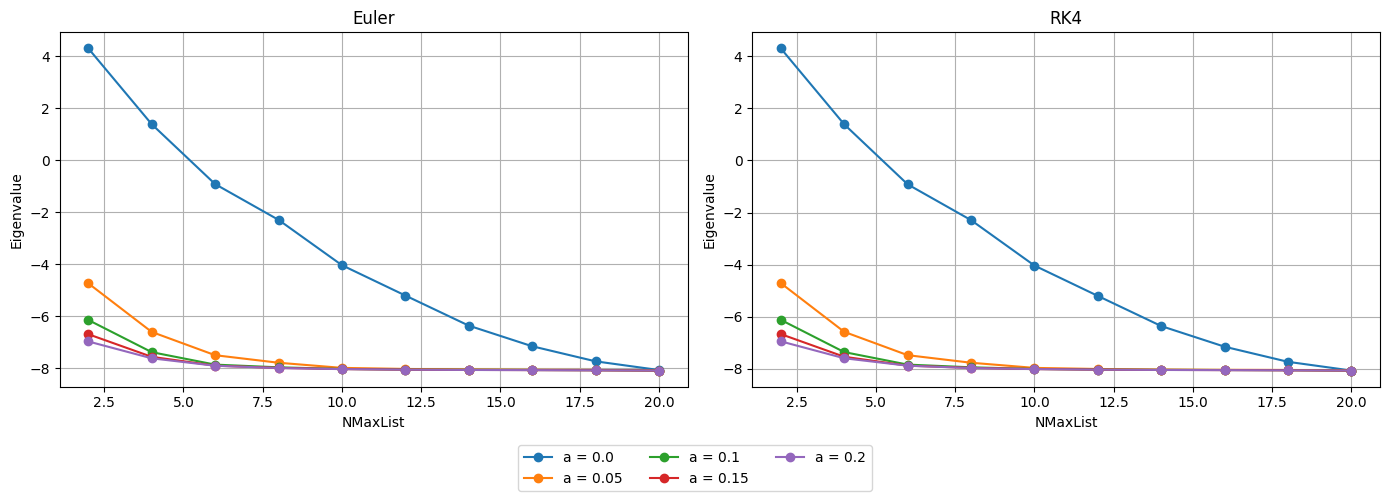

In [8]:
NMaxList = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20] #number of states corresponding to the submatrices of dimension specified below
DimList = [5, 15, 34, 64, 108, 169, 249, 351, 478, 632] #size of the submatrices
EEListEuler = {}
EEListRK4 = {}

def min_eigenvalue_submat(dim, VMatSRG):
    HMat = TMat + VMatSRG
    HSubMat = HMat[:dim, :dim]
    Eigenvalues = np.linalg.eigvalsh(HSubMat) 
    Min_Eigenvalue = Eigenvalues[0]
    return Min_Eigenvalue   

# Find minimum eigenvalue for each submatrix
for i in range(NElements):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    print(f"for a = {a}")

    EEListEuler[a] = []
    EEListRK4[a] = []

    for j in range(len(NMaxList)):
        EE0 = min_eigenvalue_submat(DimList[j], VMatEuler[a])
        EEListEuler[a].append([NMaxList[j], EE0])
        EE0 = min_eigenvalue_submat(DimList[j], VMatRK4[a])
        EEListRK4[a].append([NMaxList[j], EE0])

    print("Euler: ", EEListEuler[a])
    print("RK4: ", EEListRK4[a])

# Plot the obtained lists
figure, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(NElements):
    a = a0 + i * MatIndexDistance
    a = np.round(a, 5)
    
    x, y = zip(*EEListEuler[a])
    axes[0].plot(x, y, label=f"a = {a}", marker='o')

    x, y = zip(*EEListRK4[a])
    axes[1].plot(x, y, label=f"a = {a}", marker='o')

axes[0].set_title("Euler")
axes[1].set_title("RK4")

for ax in axes:
    ax.set_xlabel("NMaxList")
    ax.set_ylabel("Eigenvalue")
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
figure.legend(handles, labels, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()
